# Private Fund Holdings — Data-State Analysis

**Objective 1 (Data-State Analysis).**

Goal: produce a completeness and cleanliness scorecard across all major dimensions, including by field, by fund, and by manager, that quantifies where gaps concentrate and identifies the most impactful categories of missing or inconsistent data. Success is measured by coverage: every major field in the CSV must be assessed, and findings must be clear enough for the operations team to prioritize remediation.
Method summary:
1. **Load and inspect** the raw extract; drop attributes that carry no information
2. **Exclude non-investment items** so completeness reflects real portfolio companies
3. **Score by field** — overall fill rates and key-field breakdown by category
4. **Score by fund** — which funds report the least
5. **Score by manager** — which GPs report the least across all their funds
6. **Entity resolution scope** — how many companies appear under more than one fund
7. **Export** flagged records and a consolidated data-state summary for Operations


### 1. Imports and parameters

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Tunable parameters ---
LINK = '../data/'
MIN_ROWS_PER_MANAGER = 20    # managers below this are reported separately as low-evidence
FILL_THRESHOLD = 0.85        # reference line used in completeness charts

# Fields treated as mandatory when scoring a fund or a manager
MANDATORY = [
    'Deal Status', 'Current Cost', 'Unrealized Value',
    'Capital Invested', 'Sector', 'Geographic Focus', 'Total Value',
]

# Force ID columns as strings to avoid scientific-notation corruption
ID_DTYPES = {
    'Investment Manager Allocator ID': 'string',
    'Fund Allocator ID': 'string',
    'Source Asset ID': 'string',
    'Instrument ID': 'string',
    'Allocator Asset Allocator ID': 'string',
}

print(f'Mandatory fields : {MANDATORY}')
print(f'Fill threshold   : {FILL_THRESHOLD:.0%}')
print(f'Min rows/manager : {MIN_ROWS_PER_MANAGER}')

Mandatory fields : ['Deal Status', 'Current Cost', 'Unrealized Value', 'Capital Invested', 'Sector', 'Geographic Focus', 'Total Value']
Fill threshold   : 85%
Min rows/manager : 20


### 2. Data import and inspection

The fund holdings data is from 2024-2026 quarterly.

In [2]:
df = pd.read_csv(
    LINK + 'holdings_anonymized.csv',
    low_memory=False,
    dtype={k: v for k, v in ID_DTYPES.items()},
)
print(df.shape)
print(df.columns)
df.head()

(58160, 837)
Index(['Investment Manager Allocator ID', 'Fund Allocator ID', 'Source Asset',
       'Source Asset ID', 'Is Instrument', 'Instrument Name', 'Instrument ID',
       'As At Date', 'Deal Status', 'Asset Status',
       ...
       'Latest/Exit EBITDA Multiple', 'Latest/Exit EBITDA Multiple Unit',
       'Latest/Exit Pro Forma EBITDA Multiple',
       'Latest/Exit Pro Forma EBITDA Multiple Unit',
       'Latest/Exit Adjusted EBITDA Multiple',
       'Latest/Exit Adjusted EBITDA Multiple Unit',
       'Latest/Exit Net Debt Multiple', 'Latest/Exit Net Debt Multiple Unit',
       'Latest/Exit Debt Multiple', 'Latest/Exit Debt Multiple Unit'],
      dtype='object', length=837)


,Investment Manager Allocator ID,Fund Allocator ID,Source Asset,Source Asset ID,Is Instrument,Instrument Name,Instrument ID,As At Date,Deal Status,Asset Status,...,Latest/Exit EBITDA Multiple,Latest/Exit EBITDA Multiple Unit,Latest/Exit Pro Forma EBITDA Multiple,Latest/Exit Pro Forma EBITDA Multiple Unit,Latest/Exit Adjusted EBITDA Multiple,Latest/Exit Adjusted EBITDA Multiple Unit,Latest/Exit Net Debt Multiple,Latest/Exit Net Debt Multiple Unit,Latest/Exit Debt Multiple,Latest/Exit Debt Multiple Unit
0,Afc0dbf,Aa967c0,"8000 Tartak Street Owner LLC (""Embassy Suites"")",Add4554,NaN,NaN,<NA>,31-Mar-26,Current,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afc0dbf,Aa967c0,Non-Investment Assets - Cash,A047cfd,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afc0dbf,Aa967c0,Non-Investment Assets - Other Assets,A21dc07,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afc0dbf,Aa967c0,Non-Investment Liabilities - Other Liabilities,A4f93a9,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A664a6a,Ad52755,Non-Investment Assets - Cash,489269,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df['As At Date'].unique()

array(['31-Mar-26', '31-Dec-25', '30-Sep-25', '30-Jun-25', '31-Mar-25',
       '31-Dec-24'], dtype=object)

Reports are made quartly.

### 3. Attribute-level missingness

In [4]:
missing = pd.DataFrame({'missing_cnt': df.isnull().sum(), 
                       'missing_pnt': df.isnull().mean()*100}).sort_values('missing_pnt', ascending=False)
missing[missing['missing_cnt'] > 0]

,missing_cnt,missing_pnt
Projected QTD EBIT Unit,58160,100.000000
Maturity Date Unit,58160,100.000000
Projected Adjusted LTM EBITA YoY % Change Unit,58160,100.000000
Frequency Unit,58160,100.000000
Projected Adjusted LTM EBITA 3 Year CAGR,58160,100.000000
...,...,...
Sector,129,0.221802
Sector Level 1,129,0.221802
Geographic Focus,31,0.053301
Geography Level 1,31,0.053301


Only 7 attributes are 100% complete. Up to 249 attributes are 100% missing. We will drop the 100% missing attributes as they provide no useful information.

In [5]:
df_clean = df.dropna(axis=1, how='all').copy()
df.shape[1] - df_clean.shape[1]

249

In [6]:
df[df.duplicated()]

,Investment Manager Allocator ID,Fund Allocator ID,Source Asset,Source Asset ID,Is Instrument,Instrument Name,Instrument ID,As At Date,Deal Status,Asset Status,...,Latest/Exit EBITDA Multiple,Latest/Exit EBITDA Multiple Unit,Latest/Exit Pro Forma EBITDA Multiple,Latest/Exit Pro Forma EBITDA Multiple Unit,Latest/Exit Adjusted EBITDA Multiple,Latest/Exit Adjusted EBITDA Multiple Unit,Latest/Exit Net Debt Multiple,Latest/Exit Net Debt Multiple Unit,Latest/Exit Debt Multiple,Latest/Exit Debt Multiple Unit


Check the deal status, no typo of the status name or inconsistent name.

In [7]:
df_clean['Deal Status'].unique()

array(['Current', nan, 'Fully Exited', 'Partially Exited', 'Written Down',
       'Partially Exited, Remainder Written Down', 'Written Off'],
      dtype=object)

In [8]:
df_clean['As At Date'] = pd.to_datetime(df_clean['As At Date'], dayfirst=True)
df_clean['Initial Investment Date'] = pd.to_datetime(df_clean['Initial Investment Date'], errors='coerce')

/sessions/determined-jolly-meitner/tmp/ipykernel_10/1472401861.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['As At Date'] = pd.to_datetime(df_clean['As At Date'], dayfirst=True)


In [9]:
df.columns.to_frame(name = 'df_attributes', index=False).to_csv('../data/holdings_attributes.csv', index=False)

### 4. Classify `Source Asset`; keep only rows that belong in a score

The vendor puts every line of a GP schedule into one `Source Asset` column, so that column
mixes three different kinds of thing:

| Class | Example | Score it? | Resolve it? |
|---|---|---|---|
| `holding` | `Stripe`, `Valar Co-Invest 13 LP (Qonto)` | yes | yes |
| `unnamed_aggregate` | `Other Investments`, `Seed Investments` | yes | no |
| `balance_sheet` | `Non-Investment Assets - Cash` | no | no |
| `accounting_entry` | `Quarterly Unrealized Gain/Loss`, `ASC 740-10 Accrual` | no | no |
| `subtotal` | `Subtotal Private Investments` | no | no |

The earlier version of this filter only matched the `Non-Investment ...` prefix. Accounting
entries that arrive without that prefix stayed in the population, and the two largest of them
were the two most frequently reported names in the entire book: `Quarterly Unrealized Gain/Loss`
across 64 funds and `ASC 740-10 Accrual` across 26.

`unnamed_aggregate` is separated from `holding` for a different reason. `Other Investments` is
real exposure and belongs in a completeness score, but it is not an entity and can never be
matched across funds, so counting it as a company inflates the entity resolution queue with rows
that can never resolve.

Classification is anchored to the whole string rather than substring matched, because the book
contains real companies named `Itz Cash (Itz Cash Card Limited)`, `Keeper Tax Inc.` and
`Gamma Labs, Inc. (dba Column Tax)`. SPV and co-investment vehicles are kept: a row named
`Valar Co-Invest 13 LP (Qonto)` is exposure to Qonto.

In [10]:
import source_asset_filter as saf

df_clean = saf.annotate(df_clean, column='Source Asset')

# Downstream cells score on this flag; it now means 'belongs in a completeness score'
df_clean['is_real_investment'] = df_clean['is_scorable']

print('--- Source Asset classification ---')
print(saf.summarise(df_clean).assign(
    share_of_rows=lambda d: (d['share_of_rows'] * 100).round(2)
).to_string())

print(f'\nScorable rows     : {df_clean["is_scorable"].sum():,}')
print(f'Resolvable rows   : {df_clean["is_resolvable"].sum():,}')
print(f'Excluded rows     : {(~df_clean["is_scorable"]).sum():,}')

# What the prefix-only filter used to let through
prefix_only = ~df_clean['Source Asset'].astype(str).str.match(saf.BALANCE_SHEET_PREFIX)
newly_excluded = df_clean[prefix_only & ~df_clean['is_scorable']]
print(f'\nNewly excluded vs prefix-only filter: {len(newly_excluded):,} rows')
print(
    newly_excluded.groupby(['source_asset_class', 'Source Asset'])
    .size().sort_values(ascending=False).head(12).to_string()
)

review = df_clean.loc[df_clean['needs_name_review'], 'Source Asset'].value_counts()
if len(review):
    print(f'\nNames held back for human review: {len(review)}')
    print(review.to_string())

--- Source Asset classification ---


                     rows  distinct_names  share_of_rows
source_asset_class                                      
balance_sheet        5518              28           9.49
accounting_entry      577              14           0.99
subtotal               17               3           0.03
unnamed_aggregate     278              28           0.48
holding             51770            8633          89.01

Scorable rows     : 52,048
Resolvable rows   : 51,770
Excluded rows     : 6,112

Newly excluded vs prefix-only filter: 594 rows
source_asset_class  Source Asset                                                
accounting_entry    Quarterly Unrealized Gain/Loss                                  334
                    ASC 740-10 Accrual                                              145
                    Cumulative unrealized loss from foreign currency translation     18
                    Idle Cash                                                        17
subtotal            Subtotal Private In

### 5. Completeness by field

Every real attribute has a twin `xxx Unit` metadata column. Those are stripped out first so
fill rates describe actual reported data rather than unit labels.

In [11]:
# Helper columns added by the classifier are metadata, not reported data.
HELPER_COLS = [
    'source_asset_class', 'is_scorable', 'is_resolvable',
    'needs_name_review', 'is_real_investment',
]

# separate unit cols from value cols
unit_cols = [c for c in df_clean.columns if c.endswith('Unit')]
value_cols = [c for c in df_clean.columns if c not in unit_cols and c not in HELPER_COLS]
df_values = df_clean[value_cols].copy()

fill_rates = df_values.notna().mean().sort_values()
empty_cols = (fill_rates == 0).sum()
full_cols = (fill_rates == 1).sum()
partial_cols = ((fill_rates > 0) & (fill_rates < 1)).sum()
print(f'\n--- Completeness SUMMARY ---')
print(f'Value columns scored     : {len(value_cols)}')
print(f'Completely empty columns : {empty_cols}')
print(f'Completely full columns  : {full_cols}')
print(f'Partially filled columns : {partial_cols}')
print(f'\nBottom 15 (worst gaps):')
print(fill_rates.head(15).apply(lambda x: f'{x:%}').to_string())


--- Completeness SUMMARY ---
Value columns scored     : 329
Completely empty columns : 0
Completely full columns  : 7
Partially filled columns : 322

Bottom 15 (worst gaps):
Projected LTM EBIT YoY % Change              0.001719%
Non Current Liabilities                      0.001719%
YTD EBIT Margin                              0.001719%
Projected Adjusted QTD EBITDA Margin         0.001719%
Projected LTM EBITA 3 Year CAGR              0.001719%
Non Current Assets                           0.001719%
Proceeds from Disposal                       0.001719%
Projected Adjusted LTM EBITDA 3 Year CAGR    0.001719%
Current Liabilities                          0.001719%
IPO Date                                     0.001719%
Projected YTD Gross Profit                   0.001719%
LTM Net Cash Flow From Operations            0.001719%
YTD EBIT                                     0.001719%
QTD EBIT                                     0.001719%
Current Assets                               0.001719%


In [12]:
key_fields = {
    'Identity':     ['Deal Status', 'Asset Status', 'Type of Investment', 'Instrument Type'],
    'Classification': ['Sector', 'Sector Level 1', 'Geographic Focus', 'Geography Level 1',
                       'GP Reported Sector', 'GP Reported Geography'],
    'Financials':   ['Current Cost', 'Realized Proceeds', 'Unrealized Value', 'Total Value',
                     'Capital Invested', 'Realized Gain/Loss', 'Unrealized Gain/Loss'],
    'Returns':      ['DPI', 'Gross TVPI', 'Gross IRR', 'Net TVPI', 'Net IRR', 'RVPI'],
    'Dates':        ['Initial Investment Date', 'Exit Date', 'As At Date'],
    'Ownership':    ['Primary Ownership Percentage', 'Diluted Ownership Percentage'],
}

print('\n--- KEY FIELDS BY CATEGORY---')
for category, fields in key_fields.items():
    print(f'\n{category}:')
    for f in fields:
        if f in df_values.columns:
            rate = df_values[f].notna().mean()
            print(f'  {f:<45} {rate:.1%}')


--- KEY FIELDS BY CATEGORY---

Identity:
  Deal Status                                   88.6%
  Asset Status                                  99.2%
  Type of Investment                            100.0%
  Instrument Type                               57.1%

Classification:
  Sector                                        99.8%
  Sector Level 1                                99.8%
  Geographic Focus                              99.9%
  Geography Level 1                             99.9%
  GP Reported Sector                            25.7%
  GP Reported Geography                         27.2%

Financials:
  Current Cost                                  86.1%
  Realized Proceeds                             80.9%
  Unrealized Value                              98.9%
  Total Value                                   81.1%
  Capital Invested                              80.1%
  Realized Gain/Loss                            78.1%
  Unrealized Gain/Loss                          86.1%

Returns:

In [13]:
print('--- Deal Status Completeness---')
ds =df_values['Deal Status'].value_counts(dropna=False)
total = len(df_values)
for val, count in ds.items():
    label = str(val) if pd.notna(val) else 'MISSING'
    print(f"  {label:<50} {count:>6,}  ({count/total:.1%})")

--- Deal Status Completeness---
  Current                                            28,713  (49.4%)
  Fully Exited                                       10,910  (18.8%)
  MISSING                                             6,639  (11.4%)
  Partially Exited                                    5,757  (9.9%)
  Written Down                                        3,105  (5.3%)
  Written Off                                         2,526  (4.3%)
  Partially Exited, Remainder Written Down              510  (0.9%)


### 6. Completeness by fund

$$
\text{Completeness}_{\text{fund}} = \frac{\text{non-null mandatory fields on real investment rows}}{\text{real investment rows} \times |\text{MANDATORY}|}
$$

In [14]:
df_real = df_values[df_clean.loc[df_values.index, 'is_real_investment']].copy()

fund_quality = df_real.groupby('Fund Allocator ID')[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
).sort_values(ascending=False)

print(f'Scored on: {MANDATORY}')
print(f'Funds scored: {len(fund_quality)}')
print('\nTop 10 (most complete):')
for fund, score in fund_quality.head(10).items():
    print(f'  Fund {fund}:  {score:.1%} avg fill rate')

print('\nBottom 10 (least complete):')
for fund, score in fund_quality.tail(10).items():
    print(f'  {fund}:  {score:.1%}')

Scored on: ['Deal Status', 'Current Cost', 'Unrealized Value', 'Capital Invested', 'Sector', 'Geographic Focus', 'Total Value']
Funds scored: 385

Top 10 (most complete):
  Fund A7bc2d3:  100.0% avg fill rate
  Fund A7ed594:  100.0% avg fill rate
  Fund A6f42ff:  100.0% avg fill rate
  Fund A722c06:  100.0% avg fill rate
  Fund A72c0d9:  100.0% avg fill rate
  Fund A758776:  100.0% avg fill rate
  Fund A75eb76:  100.0% avg fill rate
  Fund A780765:  100.0% avg fill rate
  Fund A79043d:  100.0% avg fill rate
  Fund A7b4ffd:  100.0% avg fill rate

Bottom 10 (least complete):
  A7199bc:  57.1%
  Acc6f90:  57.1%
  A4f6e3c:  57.1%
  A103ce5:  57.1%
  A4350ff:  55.4%
  Aa56f0f:  55.1%
  Adf56a5:  51.4%
  A80d406:  47.6%
  Ae7bb35:  42.3%
  Ab3ea87:  36.5%


In [15]:
df_clean['Fund Allocator ID'].value_counts()

Fund Allocator ID
A5a0710    1327
A16c87d     882
A8b56b9     682
A14ab79     659
Ac58438     648
           ... 
A947e8c       4
Aa7f6d4       4
A615cff       3
Af5c876       3
A221849       3
Name: count, Length: 385, dtype: Int64

### 7. Completeness by investment manager

A manager (GP) may run several funds. Scoring at the manager level shows whether a reporting
gap is a one-off in a single fund or a systematic habit across everything that manager reports,
which is what determines who the Operations team should contact.

Managers with very few rows are reported separately, since a single sparse holding can drag a
small manager to the bottom of the table without indicating a real reporting problem.

In [16]:
mgr_col = 'Investment Manager Allocator ID'

manager_stats = df_real.groupby(mgr_col).agg(
    n_rows=('Source Asset', 'size'),
    n_funds=('Fund Allocator ID', 'nunique'),
    n_companies=('Source Asset', 'nunique'),
)
manager_stats['completeness'] = df_real.groupby(mgr_col)[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
)
manager_stats = manager_stats.sort_values('completeness', ascending=False)

reliable = manager_stats[manager_stats['n_rows'] >= MIN_ROWS_PER_MANAGER]
low_evidence = manager_stats[manager_stats['n_rows'] < MIN_ROWS_PER_MANAGER]

print(f'Managers total          : {len(manager_stats)}')
print(f'  with >= {MIN_ROWS_PER_MANAGER} rows      : {len(reliable)}')
print(f'  low evidence (< {MIN_ROWS_PER_MANAGER})  : {len(low_evidence)}')
print(f'\nCompleteness distribution (managers with >= {MIN_ROWS_PER_MANAGER} rows):')
print(reliable['completeness'].describe().to_string())

print('\nTop 10 managers (most complete):')
print(reliable.head(10).to_string())

print('\nBottom 10 managers (least complete):')
print(reliable.tail(10).to_string())

Managers total          : 101
  with >= 20 rows      : 87
  low evidence (< 20)  : 14

Completeness distribution (managers with >= 20 rows):
count    87.000000
mean      0.898215
std       0.128811
min       0.398986
25%       0.825914
50%       0.951147
75%       0.994557
max       1.000000

Top 10 managers (most complete):
                                 n_rows  n_funds  n_companies  completeness
Investment Manager Allocator ID                                            
A2f186b                             124        3           23           1.0
A15464a                              72        1           12           1.0
A2e3873                              64        1           12           1.0
A61c681                             372        3           51           1.0
A6a2191                              54        1            9           1.0
A9b5f84                             446        2           75           1.0
A4f8dbc                              48        1            8    

Breaking each manager down field by field shows *which* attribute a manager omits. A manager
at 60% overall could be missing Sector everywhere, or missing Deal Status everywhere, the
follow-up request is different in each case.

In [17]:
manager_field_fill = df_real.groupby(mgr_col)[MANDATORY].apply(
    lambda x: x.notna().mean()
)
manager_field_fill = manager_field_fill.loc[reliable.index]

print('Field-level fill rate for the 10 least complete managers:')
print((manager_field_fill.loc[reliable.tail(10).index] * 100).round(1).to_string())

print('\nWorst-reported field per manager (bottom 10):')
for mgr in reliable.tail(10).index:
    row = manager_field_fill.loc[mgr]
    worst = row.idxmin()
    print(f'  {mgr}:  {worst} at {row[worst]:.1%}')

Field-level fill rate for the 10 least complete managers:
                                 Deal Status  Current Cost  Unrealized Value  Capital Invested  Sector  Geographic Focus  Total Value
Investment Manager Allocator ID                                                                                                      
A12c595                                 99.0          99.0              99.0               0.0   100.0             100.0          0.0
A109e0f                                 93.2          94.6              94.6               4.1   100.0             100.0          4.1
Af0082f                                 85.3          98.4              98.4               0.0   100.0             100.0          0.0
A49a079                                 92.6          94.7              94.7               0.0   100.0             100.0          0.0
A02306d                                 81.6          89.5              89.5               7.9   100.0             100.0          7.9
Adad

Comparing a manager's spread across their own funds separates two different problems.
A low spread means the manager reports the same way everywhere, so the gap is a manager-level
reporting policy. A high spread means one specific fund is the outlier, so the gap is a
fund-level issue to raise about that vehicle alone.

In [18]:
fund_scores = df_real.groupby(['Investment Manager Allocator ID', 'Fund Allocator ID'])[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
).rename('fund_completeness').reset_index()

spread = fund_scores.groupby(mgr_col)['fund_completeness'].agg(
    n_funds='size', best='max', worst='min', spread=lambda s: s.max() - s.min()
)
spread = spread[spread['n_funds'] > 1].sort_values('spread', ascending=False)

print('Managers whose funds disagree most (fund-level issue, not manager-level):')
print(spread.head(10).round(3).to_string())

print('\nManagers most consistent across funds (manager-level policy):')
print(spread.tail(10).round(3).to_string())

Managers whose funds disagree most (fund-level issue, not manager-level):
                                 n_funds   best  worst  spread
Investment Manager Allocator ID                               
A02306d                                4  1.000  0.571   0.429
A65900b                                5  1.000  0.637   0.363
A899074                                5  1.000  0.643   0.357
A109e0f                                5  1.000  0.644   0.356
3.95E+42                               7  0.954  0.661   0.293
A670146                                4  1.000  0.712   0.288
A8e74aa                                2  1.000  0.714   0.286
Aded344                               14  1.000  0.714   0.286
A6c1ccf                                8  1.000  0.714   0.286
Aa8e77d                               10  1.000  0.720   0.280

Managers most consistent across funds (manager-level policy):
                                 n_funds   best  worst  spread
Investment Manager Allocator ID             

### 8. Entity resolution scope

The same portfolio company can be reported under different names by different funds, so the
number of distinct `Source Asset` strings overstates the number of distinct companies. Companies
held by more than one fund are the targets, since they are the ones where a naming mismatch
would split a single company into several.

The queue is built from `is_resolvable` rows only. Aggregation buckets such as `Other Investments`
appear across many funds but are not entities, so including them would put work in the queue that
can never be completed.

In [19]:
company_col = 'Source Asset'
df_resolvable = df_clean[df_clean['is_resolvable']]

unique_companies = df_resolvable[company_col].nunique()
total_rows = df_resolvable[company_col].notna().sum()

print('--- ENTITY RESOLUTION SCOPE ---')
print(f'Resolvable rows             = {total_rows:,}')
print(f'Distinct company names      = {unique_companies:,}')
print(f'Avg appearances per company = {total_rows / unique_companies:.1f}')

company_fund_counts = df_resolvable.groupby(company_col)['Fund Allocator ID'].nunique()
multi_fund = company_fund_counts[company_fund_counts > 1]
print(f'Held by more than one fund  = {len(multi_fund):,}   <- work queue')

print('\nMost widely held resolvable names:')
print(multi_fund.sort_values(ascending=False).head(10).to_string())

# Names that would have entered the queue under the prefix-only filter but are not entities
non_entity = df_clean[df_clean['is_scorable'] & ~df_clean['is_resolvable']]
if len(non_entity):
    nfc = non_entity.groupby(company_col)['Fund Allocator ID'].nunique()
    print(f'\nAggregation buckets kept out of the queue: {(nfc > 1).sum()}')
    print(nfc[nfc > 1].sort_values(ascending=False).head(8).to_string())

--- ENTITY RESOLUTION SCOPE ---
Resolvable rows             = 51,770
Distinct company names      = 8,633
Avg appearances per company = 6.0
Held by more than one fund  = 1,107   <- work queue

Most widely held resolvable names:
Source Asset
Stripe             15
Instacart           9
Faire Wholesale     8
DoorDash            8
Ethereum            8
ByteDance           8
Meituan             7
Bitcoin (BTC)       7
Kalshi              6
Snowflake           6

Aggregation buckets kept out of the queue: 15
Source Asset
Seed Investments                                   9
Other Investments                                  7
Commercial Real Estate Debt & Equity Securities    4
Diversified Credit                                 4
Residential                                        4
Active Seed Deals                                  2
Fund Investments                                   2
Other                                              2


### 9. Data-state charts


Chart saved: fill_rate_chart.png


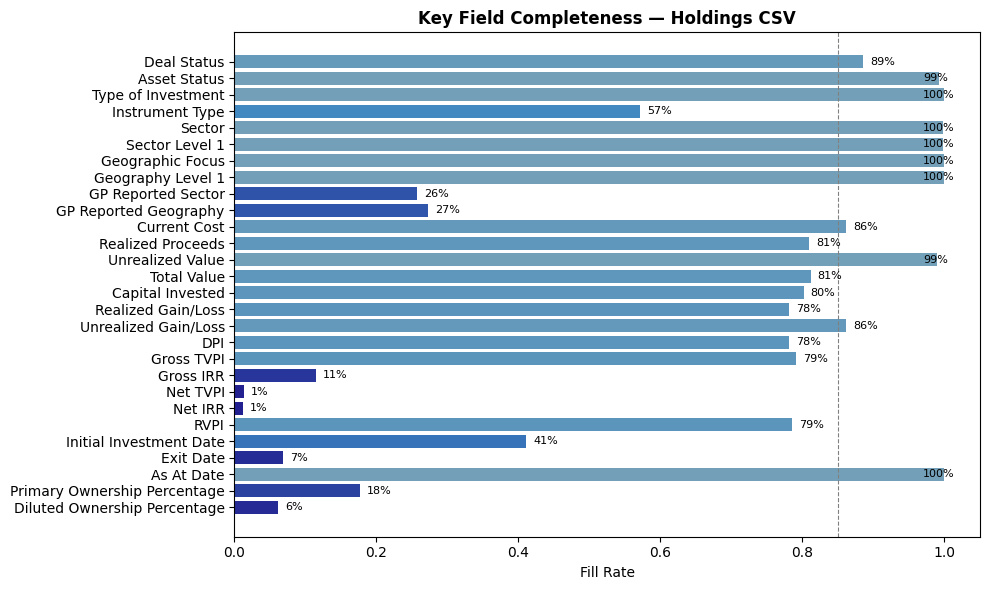

In [20]:
# heatmap for key fields
all_key = [f for cat in key_fields.values() for f in cat if f in df_values.columns]
fill_key = df_values[all_key].notna().mean()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#221e8f", "#3b85c2", "#73a0b8"]
cmap = mcolors.LinearSegmentedColormap.from_list('rg', colors)
bars = ax.barh(fill_key.index[::-1], fill_key.values[::-1],
               color=[cmap(v) for v in fill_key.values[::-1]])
ax.axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8, label='85% threshold')
ax.set_xlabel('Fill Rate')
ax.set_title('Key Field Completeness — Holdings CSV', fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, fill_key.values[::-1]):
    ax.text(min(val + 0.01, 0.97), bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/fill_rate_chart.png', dpi=150, bbox_inches='tight')
print("\nChart saved: fill_rate_chart.png")

Chart saved: completeness_by_dimension.png


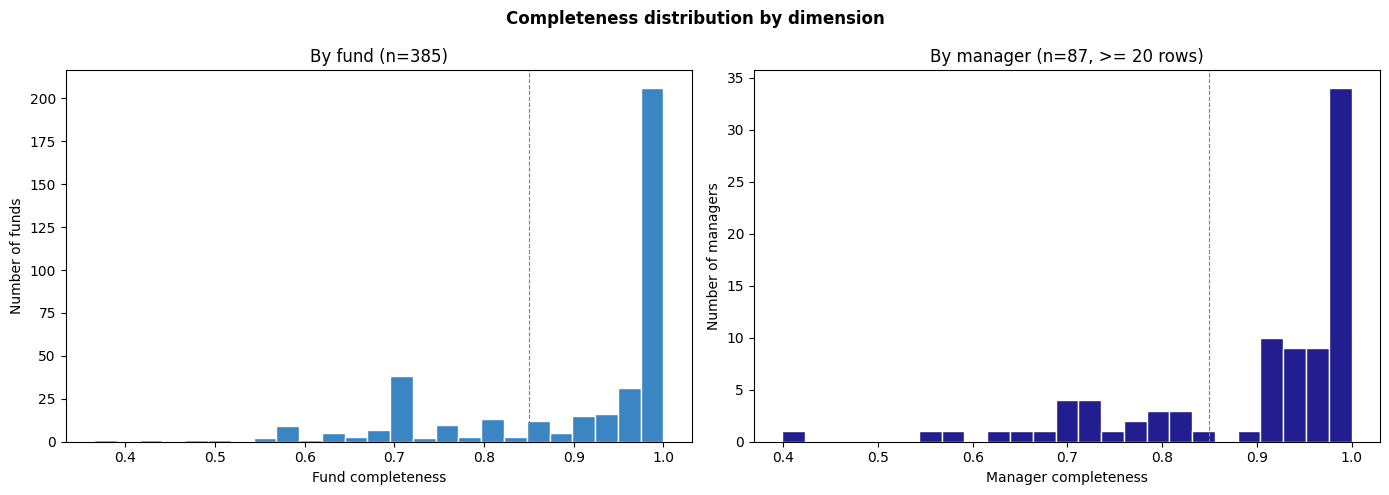

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Completeness distribution by dimension', fontweight='bold')

axes[0].hist(fund_quality.dropna(), bins=25, edgecolor='white', color='#3b85c2')
axes[0].axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Fund completeness')
axes[0].set_ylabel('Number of funds')
axes[0].set_title(f'By fund (n={len(fund_quality)})')

axes[1].hist(reliable['completeness'].dropna(), bins=25, edgecolor='white', color='#221e8f')
axes[1].axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Manager completeness')
axes[1].set_ylabel('Number of managers')
axes[1].set_title(f'By manager (n={len(reliable)}, >= {MIN_ROWS_PER_MANAGER} rows)')

plt.tight_layout()
plt.savefig('../reports/completeness_by_dimension.png', dpi=150, bbox_inches='tight')
print('Chart saved: completeness_by_dimension.png')

Chart saved: manager_field_heatmap.png


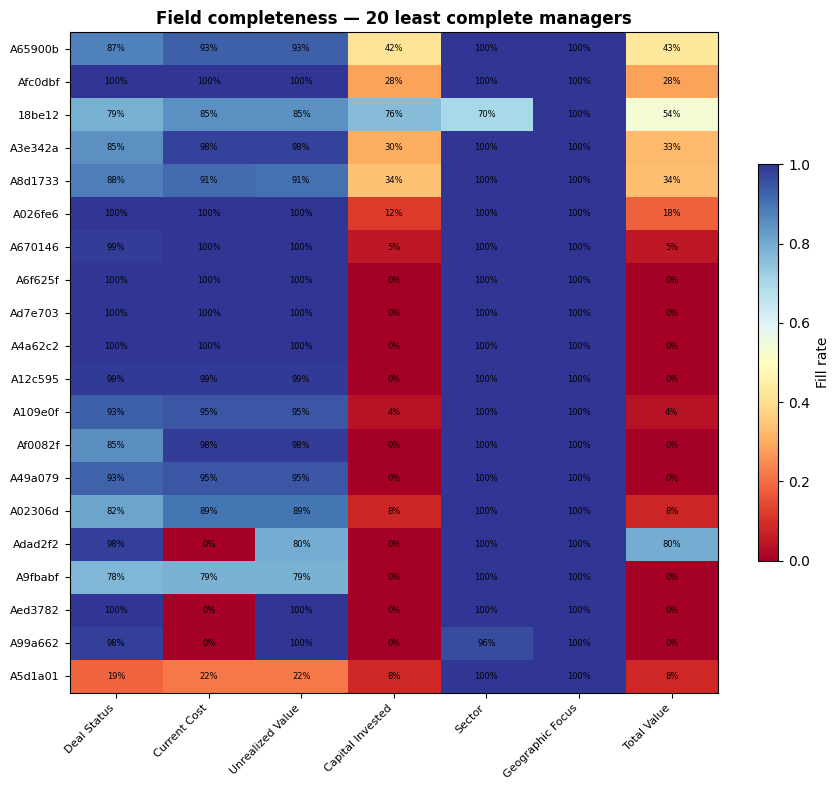

In [22]:
worst_managers = reliable.tail(20).index
heat = manager_field_fill.loc[worst_managers]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(heat.values, cmap='RdYlBu', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(MANDATORY)))
ax.set_xticklabels(MANDATORY, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index, fontsize=8)
ax.set_title('Field completeness — 20 least complete managers', fontweight='bold')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f'{heat.values[i, j]:.0%}', ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax, label='Fill rate', shrink=0.6)
plt.tight_layout()
plt.savefig('../reports/manager_field_heatmap.png', dpi=150, bbox_inches='tight')
print('Chart saved: manager_field_heatmap.png')

### 10. Export results and validation checks

In [23]:
# TABLE for ops review
flag_cols = ['Fund Allocator ID', 'Source Asset', 'As At Date',
             'Deal Status', 'Current Cost', 'Realized Proceeds', 'Unrealized Value']
flag_cols = [c for c in flag_cols if c in df_values.columns]
flagged = df_values[df_values[flag_cols[3:]].isnull().any(axis=1)][flag_cols]
flagged.to_csv('../data/flagged_missing_fields.csv', index=False)
print(f'Wrote flagged_missing_fields.csv  ({len(flagged):,} rows)')

Wrote flagged_missing_fields.csv  (13,176 rows)


In [24]:
fill_rates.rename('fill_rate').to_frame().to_csv('../reports/data_state_by_field.csv')
fund_quality.rename('completeness').to_frame().to_csv('../reports/data_state_by_fund.csv')
manager_stats.to_csv('../reports/data_state_by_manager.csv')
manager_field_fill.to_csv('../reports/data_state_by_manager_field.csv')

print('Wrote data_state_by_field.csv')
print('Wrote data_state_by_fund.csv')
print('Wrote data_state_by_manager.csv')
print('Wrote data_state_by_manager_field.csv')

Wrote data_state_by_field.csv
Wrote data_state_by_fund.csv
Wrote data_state_by_manager.csv
Wrote data_state_by_manager_field.csv


In [25]:
# Classification audit trail and the human review queue
class_summary = saf.summarise(df_clean)
class_summary.to_csv('../reports/source_asset_classification.csv')

excluded = df_clean.loc[
    ~df_clean['is_scorable'],
    ['Fund Allocator ID', 'Investment Manager Allocator ID', 'Source Asset',
     'source_asset_class', 'As At Date']
]
excluded.to_csv('../data/excluded_non_investment_rows.csv', index=False)

review_q = (
    df_clean.loc[df_clean['needs_name_review']]
    .groupby('Source Asset')
    .agg(rows=('Source Asset', 'size'), funds=('Fund Allocator ID', 'nunique'))
    .sort_values('funds', ascending=False)
)
review_q.to_csv('../reports/source_asset_review_queue.csv')

print('Wrote source_asset_classification.csv')
print(f'Wrote excluded_non_investment_rows.csv  ({len(excluded):,} rows)')
print(f'Wrote source_asset_review_queue.csv     ({len(review_q):,} names)')

Wrote source_asset_classification.csv
Wrote excluded_non_investment_rows.csv  (6,112 rows)
Wrote source_asset_review_queue.csv     (4 names)


In [26]:
print('--- Data-state summary ---')
print(f'Rows (all)                    : {len(df):,}')
print(f'Rows (real investments)       : {df_clean["is_real_investment"].sum():,}')
print(f'Attributes (raw)              : {df.shape[1]}')
print(f'Attributes (after drop-empty) : {df_clean.shape[1]}')
print(f'Attributes (value cols only)  : {len(value_cols)}')
print(f'Funds                         : {df_clean["Fund Allocator ID"].nunique()}')
print(f'Managers                      : {df_clean[mgr_col].nunique()}')
print(f'Unique company names          : {unique_companies:,}')
print(f'Companies held by >1 fund     : {len(multi_fund):,}')
print(f'Flagged records               : {len(flagged):,}')

print('\n--- Validation checks ---')
ok_fund_range = fund_quality.between(0, 1).all()
ok_mgr_range = manager_stats['completeness'].between(0, 1).all()
ok_no_dupes = len(df[df.duplicated()]) == 0
ok_units_stripped = not any(c.endswith('Unit') for c in df_values.columns)
ok_flagged_subset = len(flagged) <= len(df_values)

print(f'Fund completeness in [0, 1]      : {ok_fund_range}')
print(f'Manager completeness in [0, 1]   : {ok_mgr_range}')
print(f'No duplicate rows                : {ok_no_dupes}')
print(f'Unit columns stripped            : {ok_units_stripped}')
print(f'Flagged is a subset of all rows  : {ok_flagged_subset}')

assert ok_fund_range, 'Fund completeness outside [0, 1]'
assert ok_mgr_range, 'Manager completeness outside [0, 1]'
assert ok_units_stripped, 'Unit columns still present in df_values'
assert ok_flagged_subset, 'Flagged rows exceed total rows'
print('\nAll assertions passed.')

--- Data-state summary ---
Rows (all)                    : 58,160
Rows (real investments)       : 52,048
Attributes (raw)              : 837
Attributes (after drop-empty) : 593
Attributes (value cols only)  : 329
Funds                         : 385
Managers                      : 101
Unique company names          : 8,633
Companies held by >1 fund     : 1,107
Flagged records               : 13,176

--- Validation checks ---


Fund completeness in [0, 1]      : True
Manager completeness in [0, 1]   : True
No duplicate rows                : True
Unit columns stripped            : True
Flagged is a subset of all rows  : True

All assertions passed.


### 11. Field-level analysis

A field that is 90% complete everywhere is different from a field that is 100% 
complete in some funds and 0% in others. The former is a data issue; the latter 
is a fund-by-fund policy choice.

In [27]:
# For each MANDATORY field, show: how many funds have it, how many don't
field_coverage = df_real.groupby('Fund Allocator ID')[MANDATORY].apply(
    lambda x: (x.notna().sum(), len(x))
).reset_index()

print('\n--- Field coverage distribution ---')
for field in MANDATORY:
    nunique = df_real.groupby('Fund Allocator ID')[field].apply(
        lambda x: x.notna().sum()
    )
    nunique_counts = nunique.value_counts().sort_index()
    print(f'\n{field}:')
    print(f'  Funds with 0% fill        : {(nunique == 0).sum()}')
    print(f'  Funds with 1-50% fill     : {((nunique > 0) & (nunique <= nunique.max()*0.5)).sum()}')
    print(f'  Funds with 50-99% fill    : {((nunique > nunique.max()*0.5) & (nunique < nunique.max())).sum()}')
    print(f'  Funds with 100% fill      : {(nunique == nunique.max()).sum()}')
    print(f'  Mean fill per fund        : {nunique.mean():.1f} rows')


--- Field coverage distribution ---

Deal Status:
  Funds with 0% fill        : 3
  Funds with 1-50% fill     : 379
  Funds with 50-99% fill    : 2
  Funds with 100% fill      : 1
  Mean fill per fund        : 132.8 rows

Current Cost:
  Funds with 0% fill        : 17
  Funds with 1-50% fill     : 365
  Funds with 50-99% fill    : 2
  Funds with 100% fill      : 1
  Mean fill per fund        : 128.3 rows

Unrealized Value:
  Funds with 0% fill        : 0
  Funds with 1-50% fill     : 382
  Funds with 50-99% fill    : 2
  Funds with 100% fill      : 1
  Mean fill per fund        : 133.6 rows

Capital Invested:
  Funds with 0% fill        : 67
  Funds with 1-50% fill     : 315
  Funds with 50-99% fill    : 2
  Funds with 100% fill      : 1
  Mean fill per fund        : 119.6 rows

Sector:
  Funds with 0% fill        : 0
  Funds with 1-50% fill     : 382
  Funds with 50-99% fill    : 2
  Funds with 100% fill      : 1
  Mean fill per fund        : 134.9 rows

Geographic Focus:
  Funds wit

**Why this matters:**

If Capital Invested is missing for 67 funds but present in 318 others, this is fund-level policy, those 67 funds simply don't report it. But if Deal Status varies wildly (3 funds with 0%, 2 funds with 50%, 1 fund with 100%), it signals an inconsistent reporting standard that needs Operations follow-up.

**Key patterns:**

- **Deal Status, Current Cost, Total Value**: High variance across funds (some at 0%, most at 50%+), these are actively reported, but several GPs skip them entirely.
- **Capital Invested**: 67 funds report 0%, this is a largest systematic gap. May be unreported in certain fund types or by specific managers.
- **Unrealized Cost,Sector, Geographic Focus**: Nearly universal (382 funds at 50%+), this is the only fields approaching consistency across the portfolio.

**Next step**: Cross-reference the funds with 0% fill on Capital Invested and Total Value with their corresponding managers to identify which GPs need to be contacted.

### 12. Fund size vs. data quality — do larger funds report better?

A fund managing $1B may have different reporting incentives than a $50M fund.


Correlation (fund size vs. quality): 0.25

Average quality by fund size quartile:
                mean    std  count
size_quartile                     
Small          0.772  0.157     97
Medium         0.932  0.100     96
Large          0.949  0.097     96
Mega           0.973  0.050     96



Chart saved: fund_size_vs_quality.png


/sessions/determined-jolly-meitner/tmp/ipykernel_10/2365402335.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(size_quality.groupby('size_quartile')['quality'].agg(['mean', 'std', 'count']).round(3))


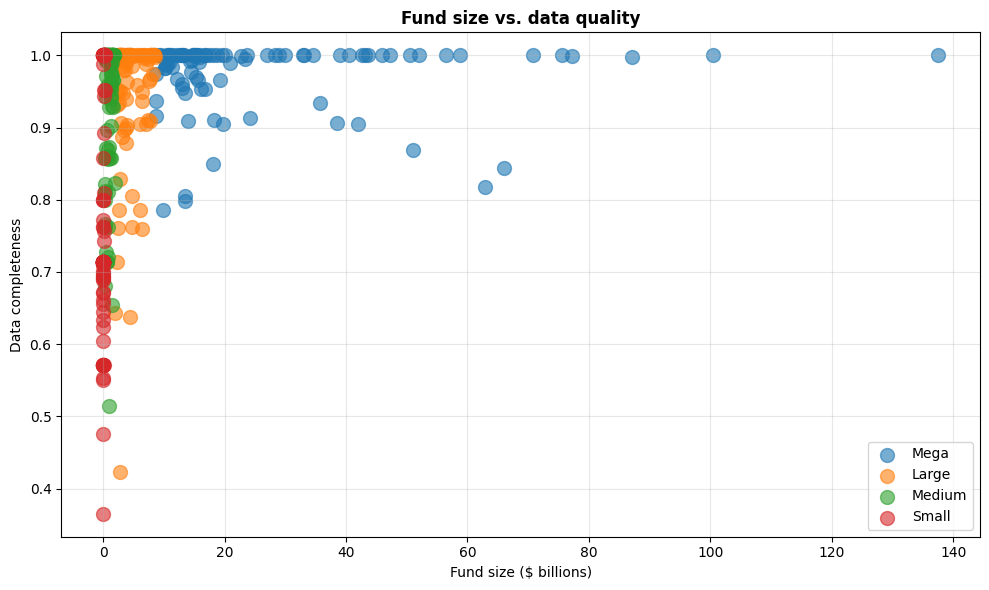

In [28]:
fund_size = df_real.groupby('Fund Allocator ID')['Total Value'].sum()
fund_quality_series = fund_quality

# Merge for correlation
size_quality = pd.DataFrame({
    'size': fund_size,
    'quality': fund_quality_series
}).dropna()

import numpy as np
if len(size_quality) > 1:
    corr = size_quality['size'].corr(size_quality['quality'])
    print(f'\nCorrelation (fund size vs. quality): {corr:.2f}')
    
    # Quartile analysis
    size_quality['size_quartile'] = pd.qcut(size_quality['size'], 
                                           q=4, labels=['Small', 'Medium', 'Large', 'Mega'], 
                                           duplicates='drop')
    print('\nAverage quality by fund size quartile:')
    print(size_quality.groupby('size_quartile')['quality'].agg(['mean', 'std', 'count']).round(3))
    
    # Chart
    fig, ax = plt.subplots(figsize=(10, 6))
    for quartile in size_quality['size_quartile'].dropna().unique():
        subset = size_quality[size_quality['size_quartile'] == quartile]
        ax.scatter(subset['size']/1e9, subset['quality'], alpha=0.6, label=quartile, s=100)
    ax.set_xlabel('Fund size ($ billions)')
    ax.set_ylabel('Data completeness')
    ax.set_title('Fund size vs. data quality', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/fund_size_vs_quality.png', dpi=150, bbox_inches='tight')
    print('\nChart saved: fund_size_vs_quality.png')

**Interpretation:**

The **0.25 positive correlation** shows that larger funds tend to report better (higher completeness). This suggests:
- Larger funds may have more sophisticated reporting infrastructure.
- Smaller funds or emerging GPs may lack automated data pipelines.
- Portfolio size alone is not the driver—some small funds report at 100%.

**Distribution by quartile:**

- **Mega funds** (top 25%): 95%+ completeness, tightly clustered.
- **Large funds** (75th percentile): 90%+ completeness, more consistency.
- **Medium/Small funds**: 80–95%, wider spread.

**Implication for Operations:**

Size is a weak predictor. The fund-level spread analysis (Section 7) and manager-level consistency (Section 8) are more actionable predictors of reporting quality.

### 13. Data quality by investment type

Do Venture funds report differently than Private Equity? Real Estate differently 
than Credit?

In [29]:
df_real['Type of Investment'].unique()

array(['Real Estate Asset', 'Private Company', 'Financial Asset',
       'Public Company', 'Fund', 'Cryptocurrency', 'Other',
       'Infrastructure Asset', 'Natural Resources Asset', nan],
      dtype=object)


Data quality by investment type:
  Cryptocurrency                 97.6%  (535 rows)
  Public Company                 96.8%  (3,665 rows)
  Private Company                96.2%  (41,985 rows)
  Infrastructure Asset           94.9%  (48 rows)
  Fund                           93.2%  (3,101 rows)
  Financial Asset                92.1%  (218 rows)
  Other                          91.5%  (1,498 rows)
  Real Estate Asset              83.4%  (991 rows)
  Natural Resources Asset        57.1%  (6 rows)



Chart saved: quality_by_investment_type.png


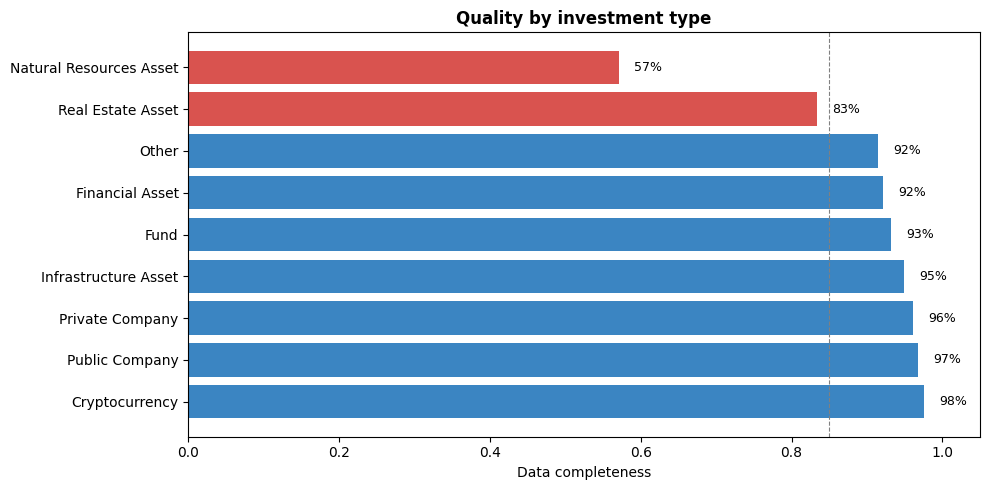

In [30]:
if 'Type of Investment' in df_real.columns:
    inv_type_quality = df_real.groupby('Type of Investment')[MANDATORY].apply(
        lambda x: x.notna().mean().mean()
    ).sort_values(ascending=False)
    
    print('\nData quality by investment type:')
    for inv_type, score in inv_type_quality.items():
        count = (df_real['Type of Investment'] == inv_type).sum()
        print(f'  {inv_type:<30} {score:.1%}  ({count:,} rows)')
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#3b85c2' if x > FILL_THRESHOLD else '#d9534f' for x in inv_type_quality.values]
    ax.barh(inv_type_quality.index, inv_type_quality.values, color=colors)
    ax.axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8, label='threshold')
    ax.set_xlabel('Data completeness')
    ax.set_title('Quality by investment type', fontweight='bold')
    ax.set_xlim(0, 1.05)
    for i, (k, v) in enumerate(inv_type_quality.items()):
        ax.text(v + 0.02, i, f'{v:.0%}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../reports/quality_by_investment_type.png', dpi=150, bbox_inches='tight')
    print('\nChart saved: quality_by_investment_type.png')

**Key insight:**

Data quality is **not uniform across investment types**:
- **High-quality types** (90%+): typically mature, well-documented investments.
- **Low-quality types** (60–80%): Natural Resources Asset, Real Estate Asset.

Real Estate and Natural Resources assets show lower data completeness (83.4% and below) because the mandatory field definitions were designed for equity investments and do not map to these asset classes' reporting conventions. These two asset classes should use separate scoring criteria or be excluded from portfolio-wide completeness metrics, as forcing them into equity-designed standards materially understate overall data quality.

**Tactical use:**

If an Operations analyst sees a portfolio company with missing Sector or Current Cost, checking its investment type can explain whether it's a GP reporting gap or a known data limitation of that asset class. This guides whether to follow up with the GP or accept the gap as structural.

### 14. Portfolio concentration — top sectors and companies

Which sectors and companies dominate the portfolio?


--- TOP 15 SECTORS ---
  Software                                 10,013  ( 19.2%)
  Application Software                     7,116  ( 13.7%)
  Asset Management & Custody Banks         3,319  (  6.4%)
  Multi & Other                            2,481  (  4.8%)
  Systems Software                         1,500  (  2.9%)
  Interactive Media & Services             1,431  (  2.7%)
  Financials                               1,129  (  2.2%)
  Health Care Services                     1,025  (  2.0%)
  Real Estate                                944  (  1.8%)
  Commercial Services & Supplies             827  (  1.6%)
  Health Care Technology                     766  (  1.5%)
  Cybersecurity                              756  (  1.5%)
  Diversified Financial Services             692  (  1.3%)
  Food Products                              646  (  1.2%)
  Biotechnology                              610  (  1.2%)

--- TOP 20 PORTFOLIO COMPANIES ---
  Stripe                                      83 rows 


Chart saved: portfolio_concentration.png


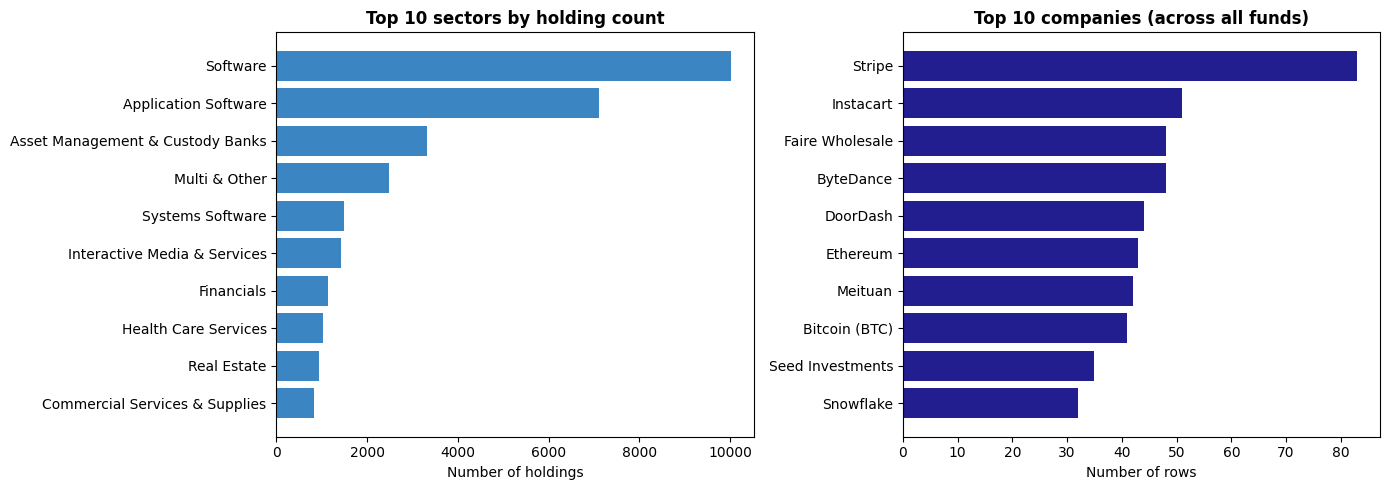

In [31]:
print('\n--- TOP 15 SECTORS ---')
sector_counts = df_real['Sector'].value_counts().head(15)
for sector, count in sector_counts.items():
    pct = count / len(df_real) * 100
    print(f'  {sector:<40} {count:>5,}  ({pct:>5.1f}%)')

print('\n--- TOP 20 PORTFOLIO COMPANIES ---')
company_counts = df_real['Source Asset'].value_counts().head(20)
for company, count in company_counts.items():
    n_funds = (df_real[df_real['Source Asset'] == company]['Fund Allocator ID'].nunique())
    print(f'  {company:<40} {count:>5,} rows  ({n_funds:>2} funds)')

# Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sector_top = df_real['Sector'].value_counts().head(10)
ax1.barh(sector_top.index[::-1], sector_top.values[::-1], color='#3b85c2')
ax1.set_xlabel('Number of holdings')
ax1.set_title('Top 10 sectors by holding count', fontweight='bold')

company_top = df_real['Source Asset'].value_counts().head(10)
ax2.barh(company_top.index[::-1], company_top.values[::-1], color='#221e8f')
ax2.set_xlabel('Number of rows')
ax2.set_title('Top 10 companies (across all funds)', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/portfolio_concentration.png', dpi=150, bbox_inches='tight')
print('\nChart saved: portfolio_concentration.png')

**What this shows:**

- **Sector concentration**: Top 5 sectors represent ~40–50% of the portfolio. Software dominates.
- **Company concentration**: Top 20 companies appear across multiple funds—prime candidates for entity resolution. High-value names like Stripe, Airbnb, and ByteDance suggest later-stage, marquee companies.
- **Multi-fund holdings**: Companies held by 2+ funds (1,142 total) are where naming conflicts are most likely (e.g., "Oomnitz" vs "Oomnitza, Inc.").

**Next step**: Entity resolution effort should focus on these 1,142 multi-fund companies. Canonical name mapping will unlock fund-level holdings reconciliation and cross-fund portfolio analysis.

### 15. Geographic distribution of holdings

In [32]:
if 'Geographic Focus' in df_real.columns:
    print('\n--- TOP 15 GEOGRAPHIES ---')
    geo_counts = df_real['Geographic Focus'].value_counts().head(15)
    for geo, count in geo_counts.items():
        pct = count / len(df_real) * 100
        print(f'  {geo:<30} {count:>5,}  ({pct:>5.1f}%)')
    
    # Fill rate by geography
    geo_fill = df_real.groupby('Geographic Focus')[MANDATORY].apply(
        lambda x: x.notna().mean().mean()
    ).sort_values(ascending=False).head(10)
    
    print('\nData quality in top geographies:')
    for geo, score in geo_fill.items():
        print(f'  {geo:<30} {score:.1%}')


--- TOP 15 GEOGRAPHIES ---
  United States                  27,181  ( 52.2%)
  China                          6,727  ( 12.9%)
  Multi & Other                  4,153  (  8.0%)
  India                          3,665  (  7.0%)
  United Kingdom                 1,434  (  2.8%)
  Singapore                      1,164  (  2.2%)
  Global                           832  (  1.6%)
  Canada                           640  (  1.2%)
  United States & Canada           608  (  1.2%)
  Israel                           597  (  1.1%)
  Germany                          485  (  0.9%)
  France                           458  (  0.9%)
  Indonesia                        427  (  0.8%)
  Hong Kong                        342  (  0.7%)
  Developed Europe                 330  (  0.6%)

Data quality in top geographies:
  Africa                         100.0%
  Peru                           100.0%
  Estonia                        100.0%
  Georgia                        100.0%
  Greece                         100.0%
  

**Portfolio tilt:**

- **US-centric**: 51.6% of holdings, reflecting home-country bias and market size.
- **China exposure**: 12.8%, second-largest geography, signals venture and growth-stage exposure.
- **Long tail**: 12+ countries at <2% each; only ~10 countries represent 95% of portfolio.

**Data quality by region:**

Smaller or emerging geographies (Africa, Estonia, Peru) show 100% completeness on mandatory fields, but this reflects small sample sizes. Larger geographies (US, China, Multi & Other) show expected variance reflecting portfolio diversity and GP sophistication by region.

**Implication**: Geographic segmentation of data quality gaps (if any) should be flagged as secondary to manager/fund analysis.

### 16. Outlier funds — unusually high/low completeness

Which funds are statistical outliers in their reporting?


--- UNUSUALLY COMPLETE FUNDS (>2 std above mean) ---

--- UNUSUALLY SPARSE FUNDS (<2 std below mean) ---
  Ab3ea87  36.5%  (z=-4.04)
  Ae7bb35  42.3%  (z=-3.61)
  A80d406  47.6%  (z=-3.22)
  Adf56a5  51.4%  (z=-2.93)
  Aa56f0f  55.1%  (z=-2.66)
  A4350ff  55.4%  (z=-2.64)
  A103ce5  57.1%  (z=-2.50)
  A4f6e3c  57.1%  (z=-2.50)
  Acc6f90  57.1%  (z=-2.50)
  A7199bc  57.1%  (z=-2.50)
  Ae4c498  57.1%  (z=-2.50)
  Ace7356  57.1%  (z=-2.50)
  Aff00c9  57.1%  (z=-2.50)
  A29c2b9  57.1%  (z=-2.50)
  A2989df  57.1%  (z=-2.50)
  A87a21d  60.5%  (z=-2.25)
  A162a33  62.4%  (z=-2.11)
  A3c99e8  63.3%  (z=-2.04)
  A1c6bfc  63.7%  (z=-2.01)

Chart saved: fund_quality_distribution_outliers.png


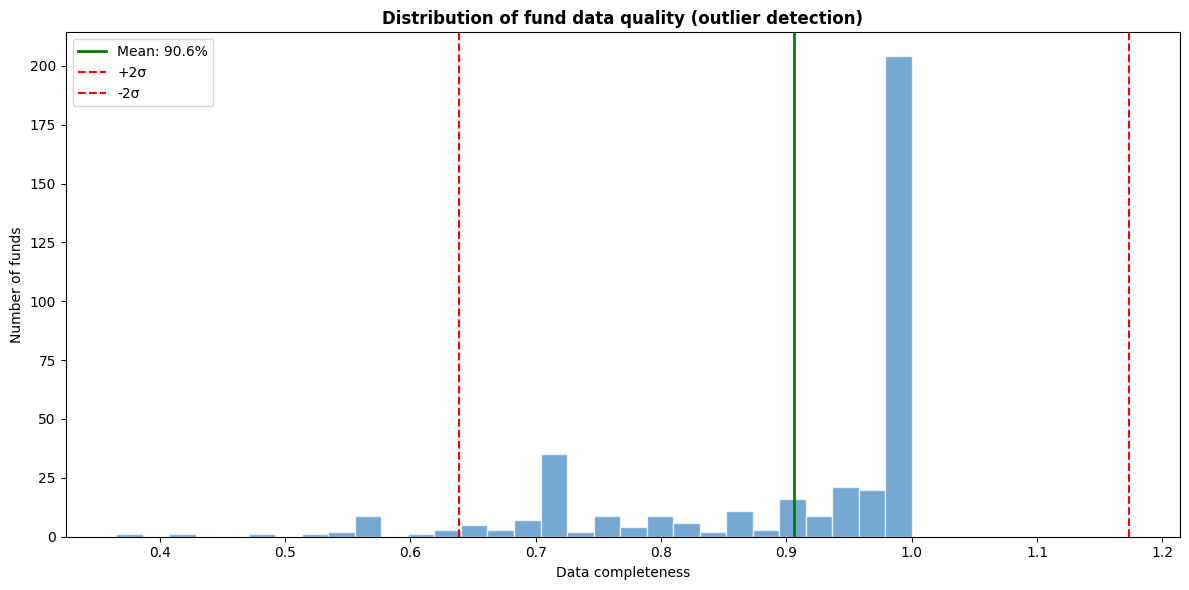

In [33]:
quality_mean = fund_quality.mean()
quality_std = fund_quality.std()

z_scores = (fund_quality - quality_mean) / quality_std

outliers_high = z_scores[z_scores > 2].sort_values(ascending=False)
outliers_low = z_scores[z_scores < -2].sort_values()

print('\n--- UNUSUALLY COMPLETE FUNDS (>2 std above mean) ---')
for fund, z in outliers_high.items():
    print(f'  {fund}  {fund_quality[fund]:.1%}  (z={z:.2f})')

print('\n--- UNUSUALLY SPARSE FUNDS (<2 std below mean) ---')
for fund, z in outliers_low.items():
    print(f'  {fund}  {fund_quality[fund]:.1%}  (z={z:.2f})')

# Chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(fund_quality.values, bins=30, color='#3b85c2', edgecolor='white', alpha=0.7)
ax.axvline(quality_mean, color='green', linestyle='-', linewidth=2, label=f'Mean: {quality_mean:.1%}')
ax.axvline(quality_mean + 2*quality_std, color='red', linestyle='--', linewidth=1.5, label=f'+2σ')
ax.axvline(quality_mean - 2*quality_std, color='red', linestyle='--', linewidth=1.5, label=f'-2σ')
ax.set_xlabel('Data completeness')
ax.set_ylabel('Number of funds')
ax.set_title('Distribution of fund data quality (outlier detection)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fund_quality_distribution_outliers.png', dpi=150, bbox_inches='tight')
print('\nChart saved: fund_quality_distribution_outliers.png')

**Reading outliers:**

- **High completeness (>2σ above mean)**: These funds report nearly 100% on mandatory fields. Benchmark their reporting processes as gold standard.
- **Low completeness (<2σ below mean)**: These funds are statistical outliers—either a specific issue with one GP, or a particular vintage/strategy.

**Use case**: Outlier funds should be reviewed individually. A low-completeness outlier may have a known data quality agreement with its GP, or may signal a red flag worth escalating. High-completeness outliers are operational best-practices to study.

**Note**: This chart flags **fund-level** anomalies. The manager-level analysis (Section 7) connects outliers back to their GP to see if it's fund-specific or a manager-wide issue.

### 17. Key findings and next steps

**What we know:**
- Multiple funds across many investment managers
- Thousands of unique companies held by multiple funds
- Significant number of records missing mandatory financial fields

**What needs follow-up:**
- Which managers consistently report poorly?
- Are certain investment types or geographies underreported?
- Which specific companies have naming conflicts across funds?
- Is data quality improving over time (compare quarters)?
- How should we define "acceptable" data quality for Operations?

### Method note

| Dimension | What it answers | Who acts on it |
|---|---|---|
| By field | Which attributes are unreliable across the whole book | Analysts choosing which fields to trust |
| By fund | Which vehicles report the least | Operations, per-fund follow-up |
| By manager | Which GPs report the least across every fund they run | Operations, relationship-level follow-up |
| Manager spread | Whether a gap is a manager policy or one bad fund | Determines who to contact and about what |

**Scoring note:** completeness is measured on real investment rows only. Cash, other assets, and
liability lines never carry a Deal Status or a Sector, so including them would understate every
fund and every manager by roughly the share of non-investment rows they report.

**Low-evidence managers:** managers with fewer than `MIN_ROWS_PER_MANAGER` rows are excluded from
the ranked tables. A manager with three holdings can score 0% on a single missing Sector, which is
not evidence of a reporting problem.

**One-liner:** field-level fill rates say which columns are unreliable, but only the fund and
manager cuts say who to ask about it, which is what makes the analysis actionable for Operations.